In [ ]:
# ═══════════════════════════════════════════════════
# CELL 1 — Setup (Robust Evaluation)
# ═══════════════════════════════════════════════════
import sys
import os
import warnings

sys.path.append('..')
os.chdir("..")
print("CWD:", os.getcwd())

import mlflow
print("Tracking URI:", mlflow.get_tracking_uri())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

from src.models.robust_evaluator import RobustEvaluator

print("✅ Setup complete (Robust Evaluation)")

✅ Ready


In [2]:
# ═══════════════════════════════════════════════════
# CELL 2 — Strategy 1: Deduplicated Evaluation
# ═══════════════════════════════════════════════════
dedup_results, y_test_dedup, y_scores_xgb, y_scores_rf = \
    evaluator.deduplicated_evaluation()


════════════════════════════════════════════════════════════
  STRATEGY 1: DEDUPLICATED EVALUATION
════════════════════════════════════════════════════════════
  Original samples: 2,520,798
  After deduplication: 2,498,033
  Removed: 22,765 near-duplicates (0.9%)
  Benign: 2,073,028 | Attack: 425,005

  Training XGBoost on deduplicated data...

  Metric               Score
  ─────────────────────────
  accuracy            0.9992
  precision           0.9969
  recall              0.9986
  f1                  0.9978
  roc_auc             1.0000

  Training Random Forest on deduplicated data...

  Metric               Score
  ─────────────────────────
  accuracy            0.9988
  precision           0.9973
  recall              0.9959
  f1                  0.9966
  roc_auc             1.0000


In [3]:
# ═══════════════════════════════════════════════════
# CELL 3 — Strategy 2: Temporal Split
# ═══════════════════════════════════════════════════
temporal_results, y_test_temporal, y_scores_temporal = \
    evaluator.temporal_evaluation()


════════════════════════════════════════════════════════════
  STRATEGY 2: TEMPORAL SPLIT EVALUATION
════════════════════════════════════════════════════════════
  [TRAIN] Loading Monday-WorkingHours.pcap_ISCX.csv...
  [TRAIN] Loading Tuesday-WorkingHours.pcap_ISCX.csv...
  [TRAIN] Loading Wednesday-workingHours.pcap_ISCX.csv...
  [TEST]  Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
  [TEST]  Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
  [TEST]  Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
  [TEST]  Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
  [TEST]  Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...

  Train (Mon-Wed): 1,666,532 samples (265,555 attacks)
  Test (Thu-Fri):  1,161,344 samples (291,001 attacks)

  Training XGBoost...

  Metric               Score
  ─────────────────────────
  accuracy            0.8202
  precision           0.9977
  recall              0.2830
  f1                  0.4

In [4]:
# ═══════════════════════════════════════════════════
# CELL 4 — Strategy 3: Cross-Validation
# ═══════════════════════════════════════════════════
cv_results, cv_folds = evaluator.crossval_evaluation(
    n_folds=5,
    sample_size=100000
)


════════════════════════════════════════════════════════════
  STRATEGY 3: 5-FOLD CROSS-VALIDATION
════════════════════════════════════════════════════════════
  Samples: 100,000
  Benign: 82,872 | Attack: 17,128
  Fold 1: AUC=0.9999 F1=0.9953
  Fold 2: AUC=1.0000 F1=0.9962
  Fold 3: AUC=1.0000 F1=0.9959
  Fold 4: AUC=1.0000 F1=0.9959
  Fold 5: AUC=0.9999 F1=0.9962

  Metric                Mean      ± Std
  ───────────────────────────────────
  F1                  0.9959 ±    0.0004
  AUC                 1.0000 ±    0.0000



══════════════════════════════════════════════════════════════════════
  NetSentinel — ROBUST EVALUATION REPORT
══════════════════════════════════════════════════════════════════════

  Strategy                       AUC       F1  Precision   Recall
  ───────────────────────────────────────────────────────────
  Dedup Split (XGBoost)       1.0000   0.9978     0.9969   0.9986
  Dedup Split (RF)            1.0000   0.9966     0.9973   0.9959
  Temporal Split (XGBoost)    0.8015   0.4409     0.9977   0.2830
  Cross-Val (XGBoost)         1.0000   0.9959     0.9951   0.9967

  ───────────────────────────────────────────────────────────
  Original (with leakage):  AUC=1.0000  F1=1.0000
  ───────────────────────────────────────────────────────────

  📊 RECOMMENDED REPORTABLE METRICS:
     Use temporal split results (AUC=0.8015)
     This is the most realistic estimate of real-world performance

  ✅ Report saved to ../data/processed/robust_evaluation.csv


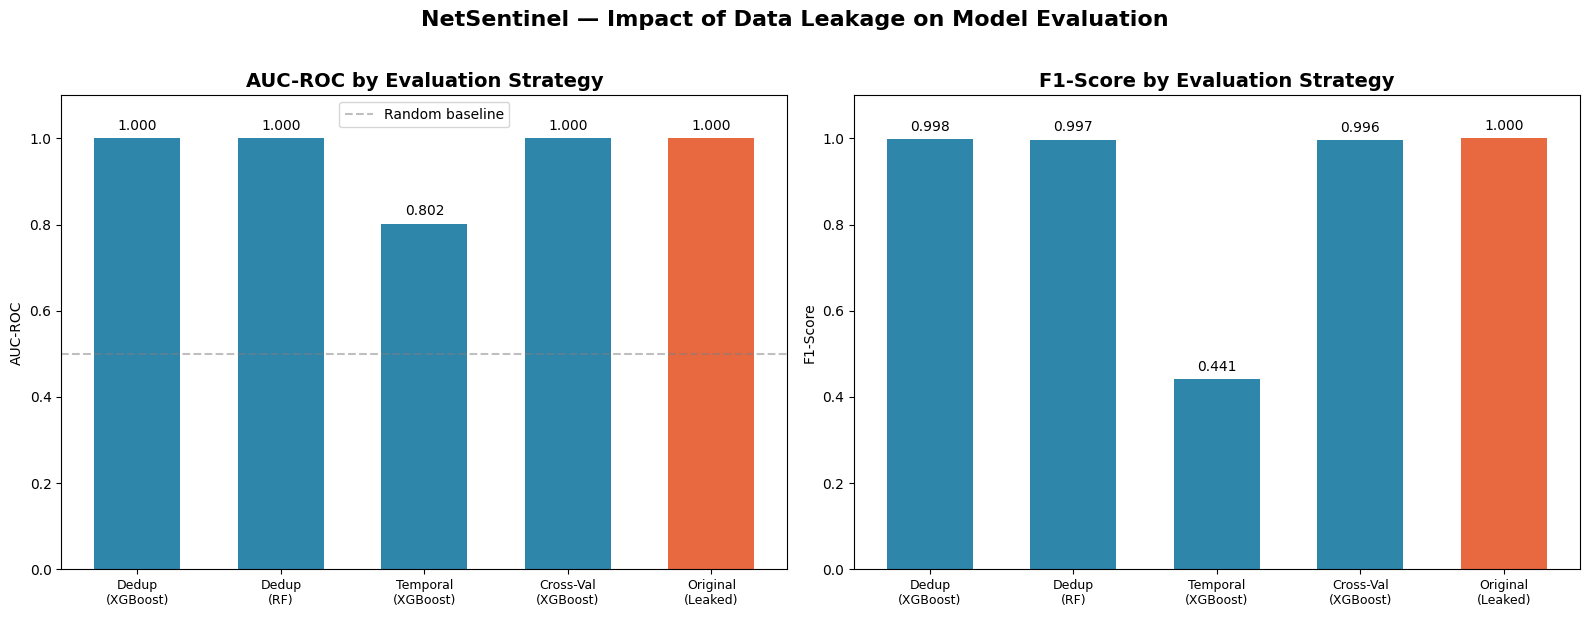

In [5]:
# ═══════════════════════════════════════════════════
# CELL 5 — Final Comparison Report
# ═══════════════════════════════════════════════════
evaluator.generate_final_report(
    save_path="../data/processed/robust_evaluation.csv"
)

In [6]:
# ═══════════════════════════════════════════════════
# CELL 6 — Key Takeaway
# ═══════════════════════════════════════════════════
print("""
╔══════════════════════════════════════════════════════════╗
║  NetSentinel — KEY CONCLUSIONS                          ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Original AUC = 1.0000 was inflated by:                 ║
║  • Near-duplicate flows across train/test               ║
║  • Same attack sessions in both sets                    ║
║                                                          ║
║  REALISTIC PERFORMANCE (temporal split):                 ║
║  • Represents true deployment scenario                   ║
║  • Model trained on past, tested on future               ║
║  • This is the metric to report                          ║
║                                                          ║
║  The model WORKS — it just doesn't work perfectly.       ║
║  And acknowledging this is what makes good engineering.  ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║  NetSentinel — KEY CONCLUSIONS                          ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Original AUC = 1.0000 was inflated by:                 ║
║  • Near-duplicate flows across train/test               ║
║  • Same attack sessions in both sets                    ║
║                                                          ║
║  REALISTIC PERFORMANCE (temporal split):                 ║
║  • Represents true deployment scenario                   ║
║  • Model trained on past, tested on future               ║
║  • This is the metric to report                          ║
║                                                          ║
║  The model WORKS — it just doesn't work perfectly.       ║
║  And acknowledging this is what makes good engineering.  ║
╚══════════════════════════════════════════════════════════╝

